Utilizzando il dataseet Diabetes, replica l'esercizio della lezione.
- Effettuare la standarizzazione dei dati
- Addestrare una regressione Ridge con 100 valori di alpha e per ognuno calcola mse e r2, determinando il miglior alpha
- Addestrare una regressione RidgeCV con stessi valori di alpha per ognuno calcolare mse e r2, determinando il migliore alpha
- Plottare i valori mse e r2, in funzione dei valori di alpha su uno stesso grafico (twinx)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

In [2]:
data=load_diabetes(as_frame=True)
X=data.data
y=data.target
print(data.feature_names)
print(X.shape)   
print(X.describe)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
(442, 10)
<bound method NDFrame.describe of           age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  

In [3]:
display(y)

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

Scalo i dati

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


inizializzo un regressione lineare per confronto sucessivo con Ridge

MSE e R2 vengono utilizzati per valutare un modello di regressione lineare.
MSE misura quanto sbagli, e gli errori sono al quadrato, errori piccoli, quasi ignorati errori grandi pesano tantissimo.
MSE pertanto 'punisce' gli errore grandi. Quindi per capire l'errore medio di MSE (errore al quadrato) bisogna calcolare la radice di MSE. 
esempio
MES=2.500  RMSE=50   errore
Attenzione, anche un solo outlier enorme fa esplodere MSE, in questo caso il modello sembra pessimo anche se è buono.
R2: il mio modello è meglio che fare una media? Confronta il risultato del modello con la media. R2 misura quando il modello è meglio della media, confrontando la somma degli errore del modello con la somma degli errore della media. R2=1-(errore modello/errore media)
Pertanto R2=1 quando errore del modello è uguale a 0 1-(0/errore media)=1
r=1 quando errore del modello =errore media (1-(errore modello/errore media))=0
L'errore del modello si ottiene confrontando y con y_pred
r2=1  errore=0 modello perfetto
r2=0  errore=errore media
tra 0 e 1 meglio della media = riduce l'errore rispetto alla media di r2%, quindi l'errore del modello è circa 100-r2% dell'errore della media
<0  peggio della media

In [5]:
lin_reg=LinearRegression()
lin_reg.fit(X_scaled,y)
y_pred_lin=lin_reg.predict(X_scaled)
#calcoliamo le metriche mse e r2
mse_lin=mean_squared_error(y,y_pred_lin)
r2_lin=r2_score(y,y_pred_lin)

print(f"MSE (Linear):\t{mse_lin:.4f} \nR2 (Linear):\t{r2_lin:.4f}")

MSE (Linear):	2859.6963 
R2 (Linear):	0.5177


Ridge

In [ ]:
r2_ridge=[]
mse_ridge=[]
alphas=np.logspace(-3,3,100)  #100 valore di alpha tra -3 e 3 (10alla3=1.000)

for a in alphas:
    ridge=Ridge(alpha=a)
    ridge.fit(X_scaled,y)
    y_pred=ridge.predict(X_scaled)
    mse_ridge.append(mean_squared_error(y,y_pred))
    r2_ridge.append(r2_score(y,y_pred))

risultato=pd.DataFrame({"alpha":alphas, "MSE": mse_ridge, "R2": r2_ridge})
display(risultato)

,alpha,MSE,R2
0,0.001000,0.524321,0.606233
1,0.001150,0.524321,0.606233
2,0.001322,0.524321,0.606233
3,0.001520,0.524321,0.606233
4,0.001748,0.524321,0.606233
...,...,...,...
95,572.236766,0.534411,0.598655
96,657.933225,0.536670,0.596958
97,756.463328,0.539325,0.594965
98,869.749003,0.542413,0.592645


plotto

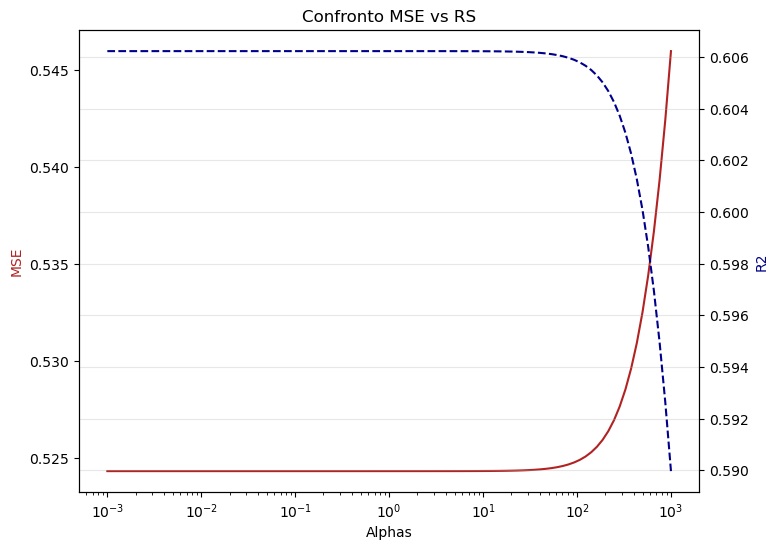

In [ ]:
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(alphas,mse_ridge,"-",color="firebrick")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE",color="firebrick")

ax2=ax1.twinx()  #l'asse x è la stessa per le due linee una a sx e l'altra a dx sempre sull'asse x
ax2.plot(alphas,r2_ridge,"--",color="darkblue")
ax2.set_ylabel("R2",color="darkblue")

plt.title("Confronto MSE vs RS")
plt.grid(alpha=0.3)
plt.legend
plt.show()

RIDGECV
Alleniamo oggetto ridgecv con la cross validation usanto lo stesso intervallo di alpha

In [13]:
alphas_cv=alphas
ridge_cv=RidgeCV(alphas=alphas_cv,store_cv_results=True)
ridge_cv.fit(X_scaled,y)
print(f"Alpha RidgeCV:\t{ridge_cv.alpha_:.4f}")

y_pred_cv=ridge_cv.predict(X_scaled)
mse_cv=mean_squared_error(y,y_pred_cv)
r2_cv=r2_score(y,y_pred_cv)

print(f"MSE:\t{mse_cv:.4f}\nR2:\t{r2_cv:.4f}")

Alpha RidgeCV:	30.5386
MSE:	0.5244
R2:	0.6062


differenza MSE tra i due oggetti (0.5243, 0.5244), mentre r2 è identico per i due modelli

quale è alpha ottimale trovato allenando 100 volte un oggetto ridge cv

In [14]:
best_idx_manuale=np.argmin(mse_ridge)
best_alpha_manuale=alphas[best_idx_manuale]
mest_mse_manuale=mse_ridge[best_idx_manuale]
best_r2_manuale=r2_ridge[best_idx_manuale]

print(f"Alpha Ridge:\t{best_alpha_manuale:.4f},\nMSE:\t{mest_mse_manuale:.4f}\nR2:\t{best_r2_manuale:.4f}")

Alpha Ridge:	0.0010,
MSE:	0.5243
R2:	0.6062


plot del mse e r2 ma con anche i valori ottimali

In [ ]:
fig,ax1=plt.subplots(figsize=(10,6))
l1=ax1.plot(alphas,mse_ridge,"-",color="firebrick",label=)
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE",color="firebrick")

ax1.scatter(best_alpha_manuale,best_idx_manuale,color="darkreg",s=150,zorder=5,label=f"alpha manuale={best_alpha_manuale}")

ax2=ax1.twinx()  #l'asse x è la stessa per le due linee una a sx e l'altra a dx sempre sull'asse x
ax2.plot(alphas,r2_ridge,"--",color="darkblue")
ax2.set_ylabel("R2",color="darkblue")

plt.title("Confronto MSE vs RS")
plt.grid(alpha=0.3)
plt.legend
plt.show()